In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:

df_temp = pd.read_csv("../../data/csv/cardiovascular_diseases.csv")

In [10]:
list_IndicatorCode = ["NCDMORT3070"]
df = df_temp[df_temp["IndicatorCode"].isin(list_IndicatorCode)].copy()

In [11]:
df.reset_index(drop=True, inplace=True)
df.columns

Index(['Unnamed: 0', 'ParentLocationCode', 'SpatialDim', 'Value',
       'NumericValue', 'TimeDimensionBegin', 'TimeDimensionEnd',
       'TimeDimensionValue', 'TimeDimType', 'TimeDim', 'IndicatorCode'],
      dtype='object')

In [12]:
df.reset_index(drop = True, inplace= True)
df.drop(columns=["Unnamed: 0"], inplace=True)
df.dropna(subset = ["ParentLocationCode"],axis = 0, inplace = True )
df["ParentLocationCode"].isnull().value_counts()

ParentLocationCode
False    12210
Name: count, dtype: int64

In [13]:
df["TimeDimensionBegin"] = pd.to_datetime(df["TimeDimensionBegin"], format="ISO8601")
print(df["TimeDimensionBegin"].isnull().value_counts())

df["TimeDimensionEnd"] = pd.to_datetime(df["TimeDimensionEnd"], format="ISO8601")
print(df["TimeDimensionEnd"].isnull().value_counts())

df["TimeDimensionValue"] = pd.to_datetime(df["TimeDimensionValue"], format="ISO8601")
print(df["TimeDimensionValue"].isnull().value_counts())

TimeDimensionBegin
False    12210
Name: count, dtype: int64
TimeDimensionEnd
False    12210
Name: count, dtype: int64
TimeDimensionValue
False    12210
Name: count, dtype: int64


In [14]:
df.groupby("IndicatorCode").count()

,ParentLocationCode,SpatialDim,Value,NumericValue,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,TimeDimType,TimeDim
IndicatorCode,,,,,,,,,
NCDMORT3070,12210,12210,12210,12210,12210,12210,12210,12210,12210


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12210 entries, 0 to 12935
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype                    
---  ------              --------------  -----                    
 0   ParentLocationCode  12210 non-null  object                   
 1   SpatialDim          12210 non-null  object                   
 2   Value               12210 non-null  object                   
 3   NumericValue        12210 non-null  float64                  
 4   TimeDimensionBegin  12210 non-null  datetime64[ns, UTC+01:00]
 5   TimeDimensionEnd    12210 non-null  datetime64[ns, UTC+01:00]
 6   TimeDimensionValue  12210 non-null  datetime64[ns]           
 7   TimeDimType         12210 non-null  object                   
 8   TimeDim             12210 non-null  int64                    
 9   IndicatorCode       12210 non-null  object                   
dtypes: datetime64[ns, UTC+01:00](2), datetime64[ns](1), float64(1), int64(1), object(5)
mem

In [16]:
df.TimeDim.unique()

array([2002, 2004, 2014, 2010, 2000, 2015, 2016, 2007, 2013, 2017, 2009,
       2011, 2018, 2003, 2012, 2006, 2021, 2001, 2019, 2008, 2020, 2005])

In [20]:
df = df[(df["TimeDim"] >=2010)&(df["TimeDim"] <=2015)]
df.TimeDim.unique()

array([2014, 2010, 2015, 2013, 2011, 2012])

<Axes: xlabel='TimeDim', ylabel='NumericValue'>

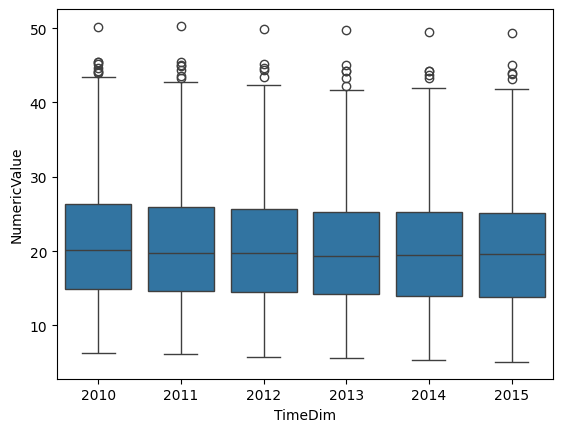

In [21]:
sns.boxplot(df, x= 'TimeDim', y = 'NumericValue')

In [22]:
df.describe()

,NumericValue,TimeDimensionValue,TimeDim
count,3330.000000,3330,3330.000000
mean,20.589009,2012-07-02 00:00:00,2012.500000
min,5.100000,2010-01-01 00:00:00,2010.000000
25%,14.300000,2011-01-01 00:00:00,2011.000000
50%,19.800000,2012-07-02 00:00:00,2012.500000
75%,25.500000,2014-01-01 00:00:00,2014.000000
max,50.300000,2015-01-01 00:00:00,2015.000000
std,8.062095,NaN,1.708082


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Numeric_final'] = scaler.fit_transform(df[['NumericValue']])


In [24]:
df.Numeric_final

2        0.230088
3        0.073009
5        0.258850
7        0.064159
9        0.188053
           ...   
12919    0.449115
12921    0.075221
12927    0.608407
12929    0.681416
12932    0.515487
Name: Numeric_final, Length: 3330, dtype: float64

In [25]:
df_outlier_scale = df[["ParentLocationCode","SpatialDim","IndicatorCode","TimeDim","Numeric_final"]]
df_outlier_scale.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3330 entries, 2 to 12932
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ParentLocationCode  3330 non-null   object 
 1   SpatialDim          3330 non-null   object 
 2   IndicatorCode       3330 non-null   object 
 3   TimeDim             3330 non-null   int64  
 4   Numeric_final       3330 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 156.1+ KB


In [26]:
df_outlier_scale.describe()

,TimeDim,Numeric_final
count,3330.000000,3330.000000
mean,2012.500000,0.342677
std,1.708082,0.178365
min,2010.000000,0.000000
25%,2011.000000,0.203540
50%,2012.500000,0.325221
75%,2014.000000,0.451327
max,2015.000000,1.000000


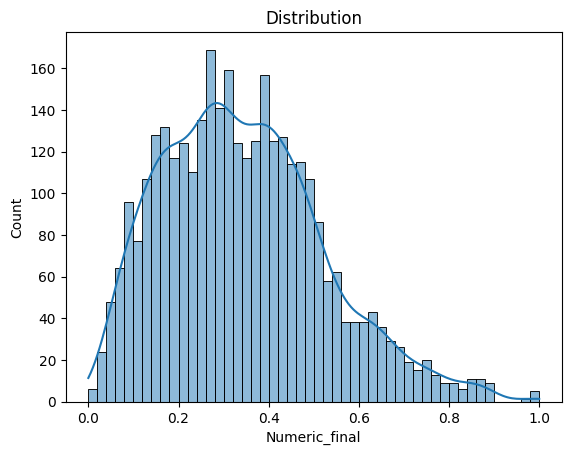

In [27]:
sns.histplot(df_outlier_scale["Numeric_final"], bins = 50, kde = True)
plt.title("Distribution")
plt.show()

In [ ]:
df.groupby(["TimeDim", "SpatialDim"])["NumericValue"].count()
#Mỗi năm, mỗi nước có 3 giá trị



TimeDim  SpatialDim
2010     AFG           3
         AGO           3
         ALB           3
         ARE           3
         ARG           3
                      ..
2015     WSM           3
         YEM           3
         ZAF           3
         ZMB           3
         ZWE           3
Name: NumericValue, Length: 1110, dtype: int64